# Posterior Repartitioning

Nested sampling runtime is set by *compression*: the number of steps scales with the
Kullback–Leibler divergence $\mathcal{D}_\mathrm{KL}(\mathcal{P}\,\|\,\pi)$ between posterior and prior. When a
vague prior encloses a tiny posterior — the usual situation in physics — almost the entire
run is spent squeezing down to the typical set, and the evidence error grows with it,
$\sigma_{\log \mathcal{Z}} \approx \sqrt{\mathcal{D}_\mathrm{KL}/n_\mathrm{live}}$.

**Posterior repartitioning** {cite}`chen2019repartitioning` removes this cost without
changing the answer. Nested sampling only requires that the product
$\mathcal{L}\pi$ stays fixed — how we split it into "likelihood" and "prior" is ours to
choose. Given any normalised *proposal prior* $\tilde\pi$,

$$
\mathcal{Z} \;=\; \int \mathcal{L}(\theta)\,\pi(\theta)\,\mathrm{d}\theta
\;=\; \int \underbrace{\left[\mathcal{L}(\theta)\,
\frac{\pi(\theta)}{\tilde\pi(\theta)}\right]}_{\tilde{\mathcal{L}}(\theta)}
\,\tilde\pi(\theta)\,\mathrm{d}\theta ,
$$

so a run with prior $\tilde\pi$ and likelihood $\tilde{\mathcal{L}} = \mathcal{L}\pi/\tilde\pi$
returns the **original** evidence exactly, while only paying the (much smaller) compression
$\mathcal{D}_\mathrm{KL}(\mathcal{P}\,\|\,\tilde\pi)$. This is the idea behind
*SuperNest* {cite}`petrosyan2023supernest`, which supplies the proposal via a Gaussian
approximation to the posterior.

The Gaussian comes from [Pathfinder](https://blackjax-devs.github.io/blackjax/)
{cite}`zhang2022pathfinder`, a cheap one-shot variational method that follows an L-BFGS
optimisation path and keeps the normal approximation with the best ELBO. It is already in
BlackJAX, so the whole thing stays in one library: Pathfinder gives us $\tilde\pi$, nested
sampling runs against it, and the $\pi/\tilde\pi$ factor leaves the evidence unchanged.

We demonstrate on the classic worst case: a broad 2D uniform prior hiding a very narrow
likelihood spike.

In [1]:
import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import tqdm

import blackjax
from blackjax.ns.utils import finalise, log_weights
from blackjax.ns.utils import sample as ns_sample

rng_key = jax.random.PRNGKey(0)

## A spike in a haystack

The prior is uniform on the box $[-10, 10]^2$; the likelihood is a correlated Gaussian pdf
with standard deviations of order $10^{-3}$ — the posterior occupies $\sim 10^{-7}$ of the
prior volume. Because $\mathcal{L}$ is normalised, the analytic evidence is simply
$\mathcal{Z} = 1/V$:

In [2]:
dim = 2
box = 10.0                            # uniform prior on [-box, box]^2
log_V = dim * jnp.log(2 * box)

like_mean = jnp.array([1.0, -1.5])
like_cov = jnp.array([[1.0, 0.6],
                      [0.6, 2.0]]) * 1e-6    # very narrow, correlated spike


def loglikelihood_fn(x):
    return jax.scipy.stats.multivariate_normal.logpdf(x, like_mean, like_cov)


def logprior_fn(x):
    inside = jnp.all(jnp.abs(x) <= box)
    return jnp.where(inside, -log_V, -jnp.inf)


logZ_analytic = -log_V   # normalized likelihood integrates to 1 inside the box

# posterior ~ N(like_mean, like_cov); its compression from the uniform prior:
dKL_direct = log_V - 0.5 * jnp.linalg.slogdet(2 * jnp.pi * jnp.e * like_cov)[1]

print(f"analytic log Z = {logZ_analytic:.3f}")
print(f"prior-to-posterior compression D_KL = {dKL_direct:.1f} nats")

analytic log Z = -5.991
prior-to-posterior compression D_KL = 16.7 nats


## The direct run

A standard `blackjax.nss` run from the uniform prior. With $n_\mathrm{live} = 500$ live
points the sampler must grind through all $\approx 17$ nats of compression, and theory
predicts an evidence error of
$\sqrt{\mathcal{D}_\mathrm{KL}/n_\mathrm{live}} \approx 0.18$.

In [3]:
num_live = 500
num_delete = 50


def run_ns(rng_key, logprior, loglike, initial_particles, **nss_kwargs):
    """Standard nss loop: iterate until the live evidence share is negligible."""
    algo = blackjax.nss(
        logprior_fn=logprior,
        loglikelihood_fn=loglike,
        num_delete=num_delete,
        num_inner_steps=10,
        **nss_kwargs,
    )
    live = algo.init(initial_particles)
    step = jax.jit(algo.step)
    dead = []
    with tqdm.tqdm(desc="Dead points", unit=" dead points") as pbar:
        while not live.integrator.logZ_live - live.integrator.logZ < -3:
            rng_key, subkey = jax.random.split(rng_key)
            live, info = step(subkey, live)
            dead.append(info)
            pbar.update(num_delete)
    return finalise(live, dead)


rng_key, init_key, run_key, w_key = jax.random.split(rng_key, 4)
initial_direct = jax.random.uniform(init_key, (num_live, dim), minval=-box, maxval=box)

run_direct = run_ns(run_key, logprior_fn, loglikelihood_fn, initial_direct)

logZ_direct = jax.scipy.special.logsumexp(
    log_weights(w_key, run_direct, shape=200), axis=0
)
n_direct = run_direct.particles.loglikelihood.shape[0]
print(f"direct run: log Z = {logZ_direct.mean():.3f} +/- {logZ_direct.std():.3f}"
      f"   ({n_direct} dead points)")

Dead points: 9950 dead points [00:01, 6758.86 dead points/s]


direct run: log Z = -6.114 +/- 0.179   (10450 dead points)


## Pathfinder finds the spike

Pathfinder is a one-shot algorithm: a single L-BFGS descent from the box centre, with a
Gaussian fitted from the optimiser's inverse-Hessian estimates along the way. We draw a
batch of samples from the returned approximation and fit an explicit
$\tilde\pi_0 = \mathcal{N}(\mu, \Sigma)$ that we can both evaluate and sample — the
proposal prior needs a normalised density.

The flat prior only shifts the log-posterior by a constant inside the box, so we hand
Pathfinder the smooth, unconstrained $\log \mathcal{L} - \log V$.

In [4]:
logdensity_fn = lambda x: loglikelihood_fn(x) - log_V

rng_key, pf_key, draw_key = jax.random.split(rng_key, 3)
pf_state, pf_info = blackjax.pathfinder.approximate(
    pf_key, logdensity_fn, jnp.zeros(dim)
)
pf_draws, _ = blackjax.pathfinder.sample(draw_key, pf_state, 1000)

mu_pf = pf_draws.mean(axis=0)
cov_pf = jnp.cov(pf_draws.T)

print("pathfinder mean:", np.array(mu_pf), "   (true:", np.array(like_mean), ")")
print("pathfinder cov / true cov:")
print(np.array(cov_pf / like_cov))

pathfinder mean: [ 0.99995553 -1.5000079 ]    (true: [ 1.  -1.5] )
pathfinder cov / true cov:
[[1.0135748  0.9191198 ]
 [0.9191198  0.97678274]]


## The repartitioned run

The proposal prior is the Pathfinder Gaussian with its covariance inflated ($2\times$ per
axis), so that $\tilde\pi$ safely encloses the posterior — if the proposal *under*-covers
the target, the correction ratio blows up in the tails. The repartitioned likelihood is

$$
\log\tilde{\mathcal{L}}(\theta) \;=\; \log\mathcal{L}(\theta) + \log\pi(\theta) - \log\tilde\pi(\theta),
$$

where $\log\pi = -\infty$ outside the box automatically zeroes any proposal leakage beyond
the original prior support. The nested sampler is simply started from draws of
$\tilde\pi$ — everything else is unchanged.

In [5]:
cov_prop = 4.0 * cov_pf     # inflate 2x per axis: proposal must enclose the posterior


def logprior_prop(x):
    return jax.scipy.stats.multivariate_normal.logpdf(x, mu_pf, cov_prop)


def loglike_repart(x):
    return loglikelihood_fn(x) + logprior_fn(x) - logprior_prop(x)


rng_key, init_key, run_key, w_key = jax.random.split(rng_key, 4)
initial_prop = jax.random.multivariate_normal(init_key, mu_pf, cov_prop, (num_live,))

run_repart = run_ns(run_key, logprior_prop, loglike_repart, initial_prop)

logZ_repart = jax.scipy.special.logsumexp(
    log_weights(w_key, run_repart, shape=200), axis=0
)
n_repart = run_repart.particles.loglikelihood.shape[0]
print(f"repartitioned run: log Z = {logZ_repart.mean():.3f} +/- {logZ_repart.std():.3f}"
      f"   ({n_repart} dead points)")

Dead points: 2100 dead points [00:01, 1639.40 dead points/s]


repartitioned run: log Z = -5.970 +/- 0.038   (2600 dead points)


## The evidence is invariant — the cost is not

Both runs return the analytic evidence, but the repartitioned run pays only
$\mathcal{D}_\mathrm{KL}(\mathcal{P}\,\|\,\tilde\pi) \lesssim 1$ nat of compression instead of
$\approx 17$. That shows up twice: **fewer dead points**, and a **smaller error bar** —
both error bars land right on the $\sqrt{\mathcal{D}_\mathrm{KL}/n_\mathrm{live}}$
prediction.

In [6]:
# D_KL(P || proposal): Gaussian-Gaussian KL divergence
diff = like_mean - mu_pf
cov_prop_inv = jnp.linalg.inv(cov_prop)
dKL_repart = 0.5 * (
    jnp.trace(cov_prop_inv @ like_cov)
    + diff @ cov_prop_inv @ diff
    - dim
    + jnp.linalg.slogdet(cov_prop)[1] - jnp.linalg.slogdet(like_cov)[1]
)

print(f"{'':>16}{'log Z':>16}{'dead points':>13}{'D_KL':>7}{'predicted err':>15}")
print(f"{'analytic':>16}{logZ_analytic:>16.3f}")
print(f"{'direct':>16}{logZ_direct.mean():>9.3f} +/- {logZ_direct.std():.3f}"
      f"{n_direct:>10}{dKL_direct:>7.1f}{jnp.sqrt(dKL_direct / num_live):>15.3f}")
print(f"{'repartitioned':>16}{logZ_repart.mean():>9.3f} +/- {logZ_repart.std():.3f}"
      f"{n_repart:>10}{dKL_repart:>7.1f}{jnp.sqrt(dKL_repart / num_live):>15.3f}")
print(f"\nrun-length reduction: {n_direct / n_repart:.1f}x")

                           log Z  dead points   D_KL  predicted err
        analytic          -5.991
          direct   -6.114 +/- 0.179     10450   16.7          0.183
   repartitioned   -5.970 +/- 0.038      2600    0.6          0.036

run-length reduction: 4.0x


## Seeing the needle

On the scale of the prior the posterior is invisible; zooming in by four orders of
magnitude shows the machinery at work — the Pathfinder proposal (dashed) enclosing the true
posterior (solid), and the repartitioned run's equally-weighted posterior draws landing on
it.

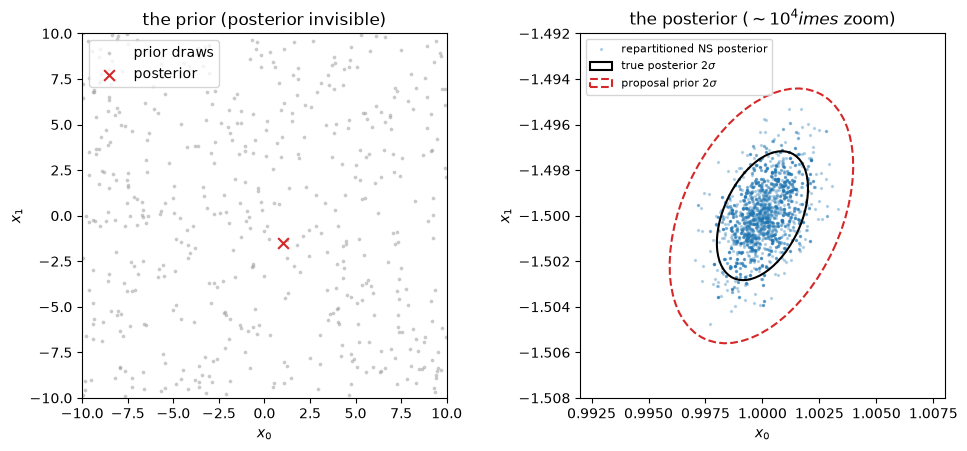

In [7]:
from matplotlib.patches import Ellipse


def cov_ellipse(ax, mean, cov, nsig, **kwargs):
    vals, vecs = np.linalg.eigh(np.asarray(cov))
    angle = np.degrees(np.arctan2(vecs[1, 1], vecs[0, 1]))
    w, h = 2 * nsig * np.sqrt(vals[1]), 2 * nsig * np.sqrt(vals[0])
    ax.add_patch(Ellipse(np.asarray(mean), w, h, angle=angle, fill=False, **kwargs))


rng_key, s_key = jax.random.split(rng_key)
post_repart = np.array(ns_sample(s_key, run_repart, 2000).position)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.6))

# left: the haystack
ax1.scatter(*np.array(initial_direct).T, s=3, alpha=0.4, color="0.6",
            label="prior draws")
ax1.scatter(*np.array(like_mean), marker="x", color="C3", s=60, label="posterior")
ax1.set_xlim(-box, box); ax1.set_ylim(-box, box)
ax1.set_aspect("equal")
ax1.set_xlabel(r"$x_0$"); ax1.set_ylabel(r"$x_1$")
ax1.set_title("the prior (posterior invisible)")
ax1.legend(loc="upper left")

# right: the needle, ~1e4x zoom
ax2.scatter(post_repart[:, 0], post_repart[:, 1], s=2, alpha=0.25, color="C0",
            label="repartitioned NS posterior")
cov_ellipse(ax2, like_mean, like_cov, 2, color="k", lw=1.5,
            label=r"true posterior $2\sigma$")
cov_ellipse(ax2, mu_pf, cov_prop, 2, color="C3", lw=1.5, ls="--",
            label=r"proposal prior $2\sigma$")
half = 0.008
ax2.set_xlim(like_mean[0] - half, like_mean[0] + half)
ax2.set_ylim(like_mean[1] - half, like_mean[1] + half)
ax2.set_aspect("equal")
ax2.set_xlabel(r"$x_0$"); ax2.set_ylabel(r"$x_1$")
ax2.set_title(r"the posterior ($\sim 10^4	imes$ zoom)")
ax2.legend(loc="upper left", fontsize=8)
fig.tight_layout()

Finally, the two runs' posteriors overlaid with
[anesthetic](https://anesthetic.readthedocs.io/) — repartitioning changed the run, not the
inference:

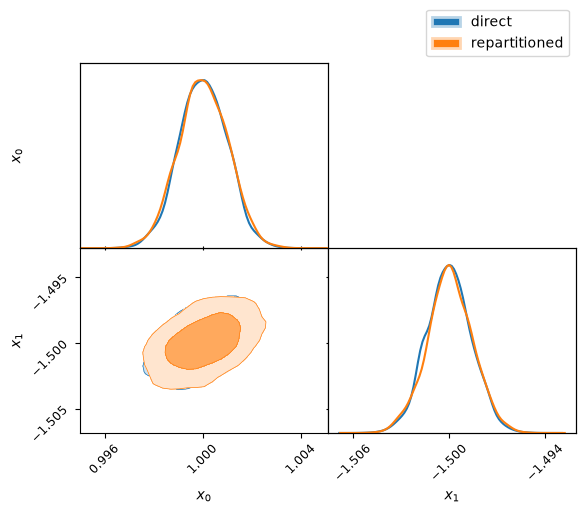

In [8]:
from anesthetic import NestedSamples

kwargs = dict(columns=["x0", "x1"], labels=[r"$x_0$", r"$x_1$"])
samples_direct = NestedSamples(
    data=run_direct.particles.position,
    logL=run_direct.particles.loglikelihood,
    logL_birth=run_direct.particles.loglikelihood_birth,
    **kwargs,
)
samples_repart = NestedSamples(
    data=run_repart.particles.position,
    logL=run_repart.particles.loglikelihood,
    logL_birth=run_repart.particles.loglikelihood_birth,
    **kwargs,
)

kinds = {"lower": "kde_2d", "diagonal": "kde_1d"}
axes = samples_direct.plot_2d(["x0", "x1"], kinds=kinds, label="direct")
samples_repart.plot_2d(axes, kinds=kinds, label="repartitioned")
axes.iloc[-1, 0].legend(bbox_to_anchor=(len(axes), len(axes)), loc="lower right");

## State caching: evaluate every density once

It is worth looking at what the repartitioned run actually evaluates. For every point the
slice sampler trials, `blackjax.nss` builds a particle state from the prior and the
likelihood *separately*:

$$
\text{prior slot: } \log\tilde\pi(x), \qquad
\text{likelihood slot: } \log\tilde{\mathcal{L}}(x) = \log\mathcal{L}(x) + \log\pi(x) - \log\tilde\pi(x),
$$

so $\tilde\pi$ is evaluated **twice per candidate**. Here it is a cheap Gaussian — and for
inline `jnp` code XLA's common-subexpression elimination will often quietly deduplicate it —
but that is compiler luck, not a contract. When the proposal is a normalizing flow, an
emulator, or sits behind a `jax.pure_callback` (as in the
[Non-JAX integration](../integrations/pytorch.ipynb) example), you pay it twice. The same
applies to any work shared between $\mathcal{L}$ and $\pi$, such as a common forward model.

This is what the `proposal` argument of `nss` is for. The shipped `covariance_proposal`
takes the function that builds a particle state as its first argument, so we can pass one
that evaluates $\mathcal{L}$, $\pi$ and $\tilde\pi$ once each and writes both the prior and
the likelihood entries of the `StateWithLogLikelihood`. The slice move is left exactly as it
was. (Setting up the initial live points still goes through the default two-call path, but
that happens only once.)

In [9]:
from functools import partial

from blackjax.ns.base import StateWithLogLikelihood, init_state_strategy
from blackjax.ns.nss import covariance_proposal


def make_repartitioned_state(loglike, logpi, logpi_prop):
    """A state strategy for repartitioned NS: each density evaluated exactly once."""

    def state_fn(position, loglikelihood_birth=jnp.nan):
        logpi_prop_x = logpi_prop(position)          # evaluated once ...
        logl_repart = loglike(position) + logpi(position) - logpi_prop_x
        return StateWithLogLikelihood(
            position=position,
            logdensity=logpi_prop_x,                 # ... reused for the prior slot
            loglikelihood=logl_repart,               # ... and the likelihood slot
            loglikelihood_birth=loglikelihood_birth * jnp.ones_like(logl_repart),
        )

    return state_fn


repartitioned_state = make_repartitioned_state(
    loglikelihood_fn, logprior_fn, logprior_prop
)


def fused_proposal(init_state_fn, loglikelihood_0, cov):
    # swap the default state strategy for the fused one; keep the shipped slice move
    return covariance_proposal(repartitioned_state, loglikelihood_0, cov)

Counting plain Python calls to each density shows the saving per candidate
evaluation — the naive split (exactly what `blackjax.nss` assembles from our
`logprior_prop` / `loglike_repart` functions, via its default `init_state_strategy`)
against the fused strategy:

In [10]:
calls = {"L": 0, "pi": 0, "pi_prop": 0}


def counted(fn, name):
    def wrapped(x):
        calls[name] += 1
        return fn(x)
    return wrapped


L_c = counted(loglikelihood_fn, "L")
pi_c = counted(logprior_fn, "pi")
prop_c = counted(logprior_prop, "pi_prop")

# what the sampler does by default: prior and likelihood slots evaluated separately
naive_state = partial(
    init_state_strategy,
    logprior_fn=prop_c,
    loglikelihood_fn=lambda x: L_c(x) + pi_c(x) - prop_c(x),
)
naive_state(like_mean)
print("density calls per candidate, naive:", dict(calls))

for k in calls:
    calls[k] = 0
make_repartitioned_state(L_c, pi_c, prop_c)(like_mean)
print("density calls per candidate, fused:", dict(calls))

density calls per candidate, naive: {'L': 1, 'pi': 1, 'pi_prop': 2}
density calls per candidate, fused: {'L': 1, 'pi': 1, 'pi_prop': 1}


Passing the fused proposal through `blackjax.nss(..., proposal=fused_proposal)`
changes nothing statistically — same evidence, same run length — it just stops paying for
$\tilde\pi$ twice:

In [11]:
rng_key, init_key, run_key, w_key = jax.random.split(rng_key, 4)
initial_fused = jax.random.multivariate_normal(init_key, mu_pf, cov_prop, (num_live,))

run_fused = run_ns(
    run_key, logprior_prop, loglike_repart, initial_fused, proposal=fused_proposal
)

logZ_fused = jax.scipy.special.logsumexp(
    log_weights(w_key, run_fused, shape=200), axis=0
)
print(f"fused repartitioned run: log Z = {logZ_fused.mean():.3f}"
      f" +/- {logZ_fused.std():.3f}"
      f"   ({run_fused.particles.loglikelihood.shape[0]} dead points)")
print(f"analytic:                log Z = {logZ_analytic:.3f}")

Dead points: 2150 dead points [00:01, 1955.27 dead points/s]


fused repartitioned run: log Z = -6.011 +/- 0.040   (2650 dead points)
analytic:                log Z = -5.991


### Wraparound for periodic parameters

Caching is a small use of a bigger freedom: the `proposal` is what decides where each trial
point goes. In `covariance_proposal` that comes down to one line,
`x = position + t * direction`, so a proposal of your own can put the point wherever you like
before it is scored.

The common reason to do this is a periodic parameter — an angle, a phase, a longitude on the
sky — where the prior's edges at $-\pi$ and $+\pi$ are the same point rather than a real
boundary. If a step runs off one end, wrapping it back to the other lets a single slice move
cross the join, rather than stopping at an artificial wall and leaving the far side to be
reached on its own. The only change from `covariance_proposal` is a modulo:

```python
from blackjax.ns.nss import sample_direction_from_covariance

def wraparound_proposal(lo, hi):
    # hit-and-run slice on a torus: candidates wrap across the [lo, hi) boundary
    span = hi - lo

    def factory(init_state_fn, loglikelihood_0, cov):
        def proposal_generator(rng_key, position, logdensity_fn):
            direction = sample_direction_from_covariance(rng_key, position, cov)

            def slice_fn(t):
                # the ONLY change from covariance_proposal: fold x back into [lo, hi)
                x = jax.tree.map(lambda p, d: lo + (p + t * d - lo) % span,
                                 position, direction)
                new_state = init_state_fn(x, loglikelihood_birth=loglikelihood_0)
                return new_state, new_state.loglikelihood > loglikelihood_0

            return slice_fn

        return proposal_generator

    return factory

# nss(..., proposal=wraparound_proposal(-jnp.pi, jnp.pi))
```

The same one line gives you a reflecting wall, or a change of variables done as the point is
built. This is the counterpart to the [Custom Inner MCMC Kernels](RW_NS.ipynb) notebook:
there you replace the sampler that links successive points; here you change where each one is
placed.

## Notes

- **The evidence bookkeeping is exact.** No post-hoc correction is applied anywhere: the
  ratio $\pi/\tilde\pi$ folded into $\tilde{\mathcal{L}}$ *is* the correction, and the run's
  evidence estimates $\mathcal{Z}$ directly. Note that `anesthetic`'s `logZ()` on the
  repartitioned samples also returns the original evidence, for the same reason.
- **The proposal must enclose the posterior.** We inflated the Pathfinder covariance; a
  proposal with thinner tails than the posterior (or one that misses a mode) sends the
  correction ratio $\pi/\tilde\pi \to \infty$ in the uncovered region and can bias
  $\mathcal{Z}$. SuperNest {cite}`petrosyan2023supernest` makes this robust by
  *superposing* proposal and original prior,
  $\tilde\pi = w\,\tilde\pi_0 + (1-w)\,\pi$, which keeps full prior support with almost all
  of the acceleration — the recommended construction beyond this pedagogical example.
- **When it matters.** The gain scales with the compression removed:
  $\mathcal{D}_\mathrm{KL}(\mathcal{P}\|\pi) - \mathcal{D}_\mathrm{KL}(\mathcal{P}\|\tilde\pi)$
  nats of runtime *and* the corresponding shrinkage of the evidence error bar. Vague priors
  over tightly-constrained physical parameters are exactly this regime.

Cited references are collected in the book-wide bibliography on the Contributors page.